In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import sqlite3
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [21]:
df = pd.read_csv('../data/layoffs_data.csv')
# Source: layoffs.fyi via Kaggle (swaptr/layoffs-2022)
# Note: pre-cleaned in Excel — removed nulls, standardized fields, filtered to Bay Area
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (100, 9)

First 5 rows:


,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions
0,Meta,Menlo Park,Social Media,11000,0.13,2022-11-09,Post-IPO,United States,16800
1,Salesforce,San Francisco,Enterprise Software,8000,0.10,2023-01-04,Post-IPO,United States,1700
2,Twitter,San Francisco,Social Media,3700,0.50,2022-11-04,Private,United States,1400
3,Stripe,San Francisco,Fintech,1100,0.14,2022-11-03,Private,United States,2200
4,DoorDash,San Francisco,Food Delivery,1250,0.06,2022-11-30,Post-IPO,United States,2500


In [22]:
print("Data Types and Missing Values:")
print(df.info())
print("\nMissing Values Count:")
print(df.isnull().sum())

Data Types and Missing Values:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company                100 non-null    str    
 1   location               100 non-null    str    
 2   industry               100 non-null    str    
 3   total_laid_off         100 non-null    int64  
 4   percentage_laid_off    100 non-null    float64
 5   date                   100 non-null    str    
 6   stage                  100 non-null    str    
 7   country                100 non-null    str    
 8   funds_raised_millions  100 non-null    int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 7.2 KB
None

Missing Values Count:
company                  0
location                 0
industry                 0
total_laid_off           0
percentage_laid_off      0
date                     0
stage                    0
country                  0
fun

In [23]:
df_clean = df.copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])

df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['quarter'] = df_clean['date'].dt.quarter
df_clean['year_quarter'] = df_clean['year'].astype(str) + '-Q' + df_clean['quarter'].astype(str)

df_clean['percentage_laid_off'] = df_clean['percentage_laid_off'] * 100

df_clean['total_laid_off'].fillna(0, inplace=True)

def categorize_layoff_size(num):
    if num == 0:
        return 'No Layoffs'
    elif num < 100:
        return 'Small (<100)'
    elif num < 500:
        return 'Medium (100-500)'
    elif num < 1000:
        return 'Large (500-1000)'
    else:
        return 'Very Large (1000+)'

df_clean['layoff_size_category'] = df_clean['total_laid_off'].apply(categorize_layoff_size)

df_clean = df_clean.drop_duplicates()

print(f"Data cleaning complete!")
print(f"Original rows: {len(df)}, Clean rows: {len(df_clean)}")
print(f"\nCleaned dataset preview:")
df_clean.head()

Data cleaning complete!
Original rows: 100, Clean rows: 100

Cleaned dataset preview:


,company,location,industry,total_laid_off,percentage_laid_off,date,stage,country,funds_raised_millions,year,month,quarter,year_quarter,layoff_size_category
0,Meta,Menlo Park,Social Media,11000,13.0,2022-11-09,Post-IPO,United States,16800,2022,11,4,2022-Q4,Very Large (1000+)
1,Salesforce,San Francisco,Enterprise Software,8000,10.0,2023-01-04,Post-IPO,United States,1700,2023,1,1,2023-Q1,Very Large (1000+)
2,Twitter,San Francisco,Social Media,3700,50.0,2022-11-04,Private,United States,1400,2022,11,4,2022-Q4,Very Large (1000+)
3,Stripe,San Francisco,Fintech,1100,14.0,2022-11-03,Private,United States,2200,2022,11,4,2022-Q4,Very Large (1000+)
4,DoorDash,San Francisco,Food Delivery,1250,6.0,2022-11-30,Post-IPO,United States,2500,2022,11,4,2022-Q4,Very Large (1000+)


In [24]:
print("Summary Statistics for Total Layoffs:")
print(df_clean['total_laid_off'].describe())

print("\nSummary Statistics for Percentage Laid Off:")
print(df_clean['percentage_laid_off'].describe())

Summary Statistics for Total Layoffs:
count      100.000000
mean       862.070000
std       1879.480555
min          0.000000
25%        150.000000
50%        300.000000
75%        625.750000
max      12000.000000
Name: total_laid_off, dtype: float64

Summary Statistics for Percentage Laid Off:
count    100.000000
mean      16.884000
std       18.364567
min        0.000000
25%        5.750000
50%       13.000000
75%       20.250000
max      100.000000
Name: percentage_laid_off, dtype: float64


In [25]:
total_layoffs = df_clean['total_laid_off'].sum()
total_companies = df_clean['company'].nunique()
avg_layoffs_per_company = total_layoffs / total_companies

print(f"Total Layoffs in Bay Area (2020-2024): {total_layoffs:,.0f}")
print(f"Number of Companies with Layoffs: {total_companies}")
print(f"Average Layoffs per Company: {avg_layoffs_per_company:,.0f}")

Total Layoffs in Bay Area (2020-2024): 86,207
Number of Companies with Layoffs: 100
Average Layoffs per Company: 862


In [26]:
industry_layoffs = df_clean.groupby('industry').agg({
    'total_laid_off': 'sum',
    'company': 'count'
}).rename(columns={'company': 'num_companies'}).sort_values('total_laid_off', ascending=False)

industry_layoffs['avg_per_company'] = industry_layoffs['total_laid_off'] / industry_layoffs['num_companies']

print("Layoffs by Industry:")
print(industry_layoffs.head(10))

Layoffs by Industry:
                     total_laid_off  num_companies  avg_per_company
industry                                                           
Social Media                  15468              5      3093.600000
Technology                    12600              2      6300.000000
Enterprise Software            8725              3      2908.333333
Fintech                        6396              9       710.666667
Transportation                 4900              2      2450.000000
Real Estate                    4562              5       912.400000
Networking                     4100              1      4100.000000
Automotive                     3500              1      3500.000000
Recruiting                     2500              2      1250.000000
E-commerce                     1977              6       329.500000


In [27]:
top_companies = df_clean.groupby('company')['total_laid_off'].sum().sort_values(ascending=False).head(15)

print("Top 15 Companies by Total Layoffs:")
print(top_companies)

Top 15 Companies by Total Layoffs:
company
Google        12000
Meta          11000
Salesforce     8000
Cisco          4100
Twitter        3700
Uber           3700
Tesla          3500
WeWork         2400
Indeed         2200
PayPal         2000
Airbnb         1900
Yahoo          1600
DoorDash       1250
Lyft           1200
Coinbase       1100
Name: total_laid_off, dtype: int64


In [28]:
yearly_layoffs = df_clean.groupby('year')['total_laid_off'].sum().sort_index()

print("Total Layoffs by Year:")
print(yearly_layoffs)

quarterly_layoffs = df_clean.groupby('year_quarter')['total_laid_off'].sum().sort_index()

print("\nTop 10 Quarters by Layoffs:")
print(quarterly_layoffs.sort_values(ascending=False).head(10))

Total Layoffs by Year:
year
2015        0
2020     7029
2021      136
2022    27536
2023    47933
2024     3573
Name: total_laid_off, dtype: int64

Top 10 Quarters by Layoffs:
year_quarter
2023-Q1    37543
2022-Q4    24336
2020-Q2     6610
2023-Q2     5486
2024-Q1     2973
2023-Q4     2926
2023-Q3     1978
2022-Q2     1840
2022-Q3     1280
2024-Q2      600
Name: total_laid_off, dtype: int64


In [29]:
stage_layoffs = df_clean.groupby('stage').agg({
    'total_laid_off': 'sum',
    'company': 'count'
}).rename(columns={'company': 'num_companies'}).sort_values('total_laid_off', ascending=False)

print("Layoffs by Company Stage:")
print(stage_layoffs)

Layoffs by Company Stage:
          total_laid_off  num_companies
stage                                  
Post-IPO           65044             61
Private            11592             23
Public              9571             16


In [30]:
location_layoffs = df_clean.groupby('location').agg({
    'total_laid_off': 'sum',
    'company': 'count'
}).rename(columns={'company': 'num_companies'}).sort_values('total_laid_off', ascending=False)

print("Layoffs by Bay Area Location:")
print(location_layoffs.head(10))

Layoffs by Bay Area Location:
               total_laid_off  num_companies
location                                    
San Francisco           41311             63
Mountain View           12100              2
Menlo Park              11780              2
San Jose                 8020              7
Palo Alto                3800              2
Sunnyvale                2516              3
Santa Clara              1185              3
San Mateo                 750              3
Seattle                   750              1
Redwood City              690              3


In [31]:
conn = sqlite3.connect('bay_area_layoffs.db')

df_clean.to_sql('layoffs', conn, if_exists='replace', index=False)

print("Database created successfully!")

Database created successfully!


In [32]:
query1 = """
SELECT 
    company,
    location,
    industry,
    SUM(total_laid_off) as total_layoffs,
    ROUND(AVG(percentage_laid_off), 2) as avg_percentage
FROM layoffs
GROUP BY company, location, industry
HAVING total_layoffs > 0
ORDER BY total_layoffs DESC
LIMIT 10;
"""

result1 = pd.read_sql_query(query1, conn)
print("Top 10 Companies by Total Layoffs (SQL Query):")
print(result1)

Top 10 Companies by Total Layoffs (SQL Query):
      company       location             industry  total_layoffs  \
0      Google  Mountain View           Technology          12000   
1        Meta     Menlo Park         Social Media          11000   
2  Salesforce  San Francisco  Enterprise Software           8000   
3       Cisco       San Jose           Networking           4100   
4     Twitter  San Francisco         Social Media           3700   
5        Uber  San Francisco       Transportation           3700   
6       Tesla      Palo Alto           Automotive           3500   
7      WeWork  San Francisco          Real Estate           2400   
8      Indeed  San Francisco           Recruiting           2200   
9      PayPal       San Jose              Fintech           2000   

   avg_percentage  
0             6.0  
1            13.0  
2            10.0  
3             5.0  
4            50.0  
5            14.0  
6            10.0  
7            40.0  
8            22.0  
9   

In [33]:
query2 = """
SELECT 
    industry,
    year,
    SUM(total_laid_off) as total_layoffs,
    COUNT(DISTINCT company) as num_companies
FROM layoffs
WHERE total_laid_off > 0
GROUP BY industry, year
ORDER BY industry, year;
"""

result2 = pd.read_sql_query(query2, conn)
print("Industry Analysis by Year (SQL Query):")
print(result2.head(20))

Industry Analysis by Year (SQL Query):
                industry  year  total_layoffs  num_companies
0             Automotive  2023           3500              1
1    Autonomous Vehicles  2023            900              1
2                 Beauty  2022             80              1
3            Car Sharing  2020            100              1
4                  Cloud  2023            300              1
5          Cloud Storage  2023            500              1
6          Communication  2023            150              1
7               Consumer  2023              8              1
8   Consumer Electronics  2022            270              1
9   Consumer Electronics  2023            130              1
10                Crypto  2022           1100              1
11      Customer Service  2023            300              1
12        Data Analytics  2023            325              1
13              Delivery  2023            250              1
14       Developer Tools  2023            300 

In [34]:
query3 = """
SELECT 
    company,
    location,
    industry,
    total_laid_off,
    ROUND(percentage_laid_off, 2) as pct_laid_off,
    stage,
    date
FROM layoffs
WHERE percentage_laid_off >= 30
ORDER BY percentage_laid_off DESC
LIMIT 15;
"""

result3 = pd.read_sql_query(query3, conn)
print("Companies with Highest Percentage Laid Off (>= 30%):")
print(result3)

Companies with Highest Percentage Laid Off (>= 30%):
         company       location       industry  total_laid_off  pct_laid_off  \
0           Bird  San Francisco  Micromobility               0         100.0   
1         Trulia  San Francisco    Real Estate               0         100.0   
2     Glu Mobile  San Francisco         Gaming               0         100.0   
3        Twitter  San Francisco   Social Media            3700          50.0   
4         Convoy        Seattle      Logistics             750          47.0   
5      Getaround  San Francisco    Car Sharing             100          41.0   
6        23andMe      Sunnyvale     Healthcare             200          40.0   
7         WeWork  San Francisco    Real Estate            2400          40.0   
8        StubHub  San Francisco      Ticketing             450          35.0   
9       Glossier  San Francisco         Beauty              80          33.0   
10         Color     Burlingame     Healthcare             136     

FileNotFoundError: [Errno 2] No such file or directory: '.../visualizations/industry_layoffs.png'

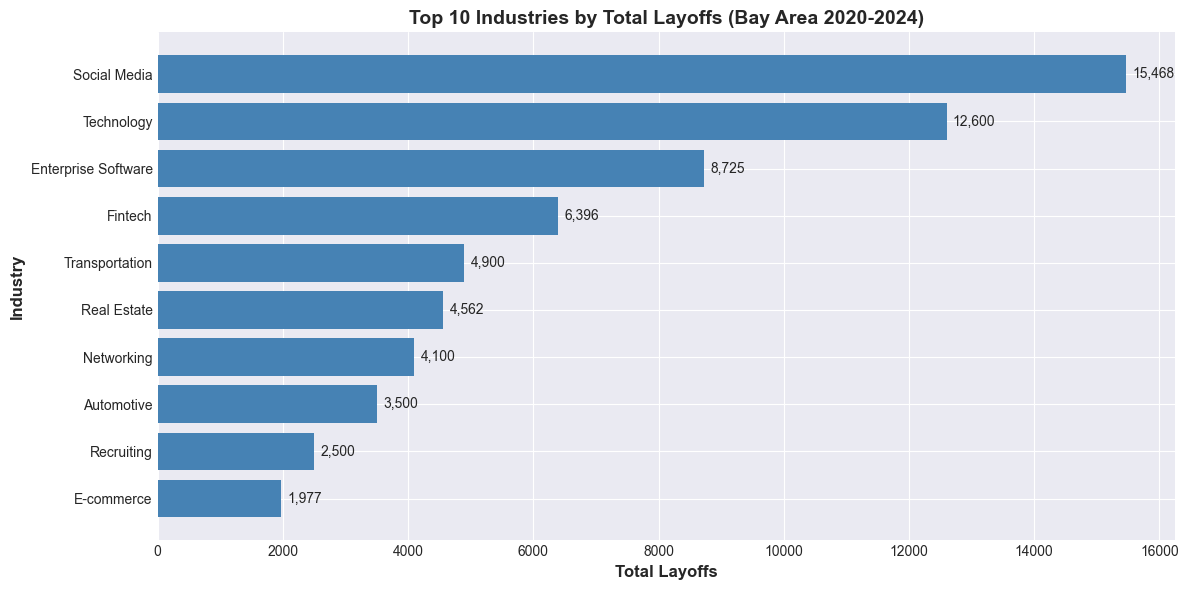

In [35]:
plt.figure(figsize=(12, 6))
top_industries = industry_layoffs.head(10)
plt.barh(top_industries.index, top_industries['total_laid_off'], color='steelblue')
plt.xlabel('Total Layoffs', fontsize=12, fontweight='bold')
plt.ylabel('Industry', fontsize=12, fontweight='bold')
plt.title('Top 10 Industries by Total Layoffs (Bay Area 2020-2024)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(top_industries['total_laid_off']):
    plt.text(v + 100, i, f'{v:,.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('.../visualizations/industry_layoffs.png', dpi=300, bbox_inches='tight')
plt.show()

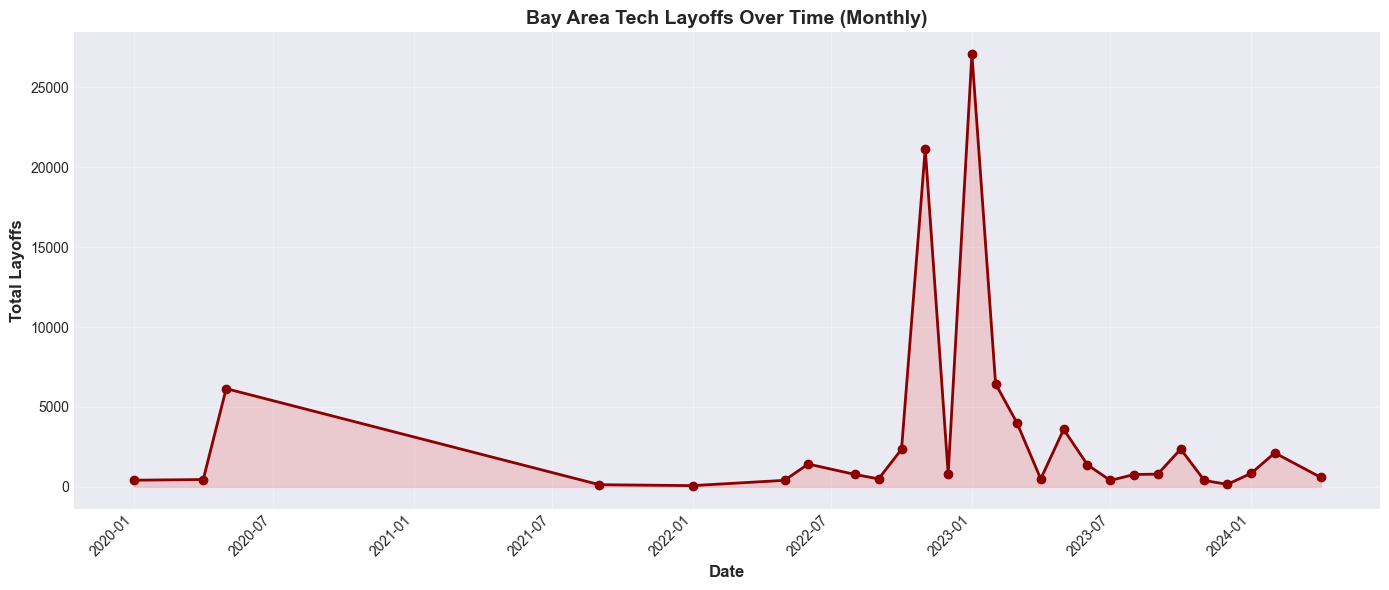

In [ ]:
plt.figure(figsize=(14, 6))
monthly_data = df_clean[df_clean['total_laid_off'] > 0].groupby(df_clean['date'].dt.to_period('M'))['total_laid_off'].sum()
monthly_data_df = pd.DataFrame({'month': monthly_data.index.to_timestamp(), 'layoffs': monthly_data.values})

plt.plot(monthly_data_df['month'], monthly_data_df['layoffs'], marker='o', linewidth=2, color='darkred')
plt.fill_between(monthly_data_df['month'], monthly_data_df['layoffs'], alpha=0.3, color='lightcoral')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Total Layoffs', fontsize=12, fontweight='bold')
plt.title('Bay Area Tech Layoffs Over Time (Monthly)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('.../visualizations/layoffs_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

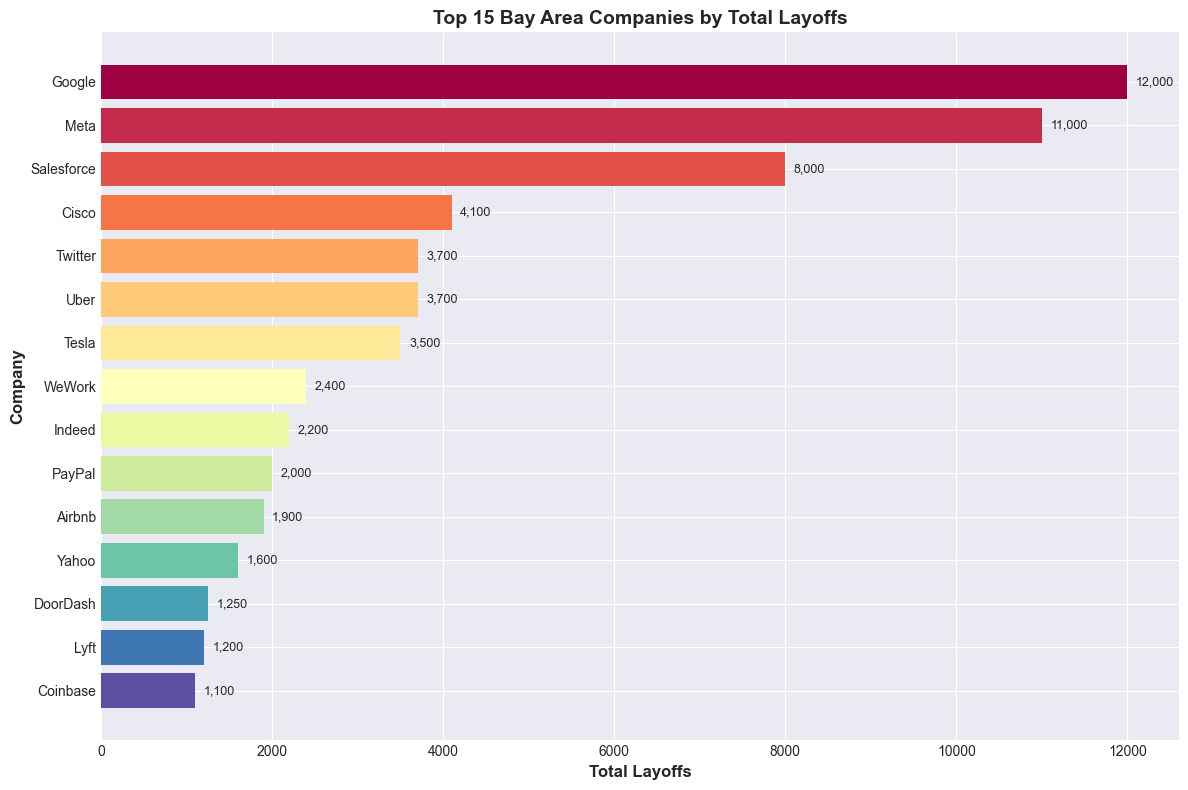

In [ ]:
plt.figure(figsize=(12, 8))
top_15_companies = df_clean.groupby('company')['total_laid_off'].sum().sort_values(ascending=False).head(15)
colors = plt.cm.Spectral(np.linspace(0, 1, 15))
plt.barh(range(len(top_15_companies)), top_15_companies.values, color=colors)
plt.yticks(range(len(top_15_companies)), top_15_companies.index)
plt.xlabel('Total Layoffs', fontsize=12, fontweight='bold')
plt.ylabel('Company', fontsize=12, fontweight='bold')
plt.title('Top 15 Bay Area Companies by Total Layoffs', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(top_15_companies.values):
    plt.text(v + 100, i, f'{v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('.../visualizations/top_companies_layoffs.png', dpi=300, bbox_inches='tight')
plt.show()

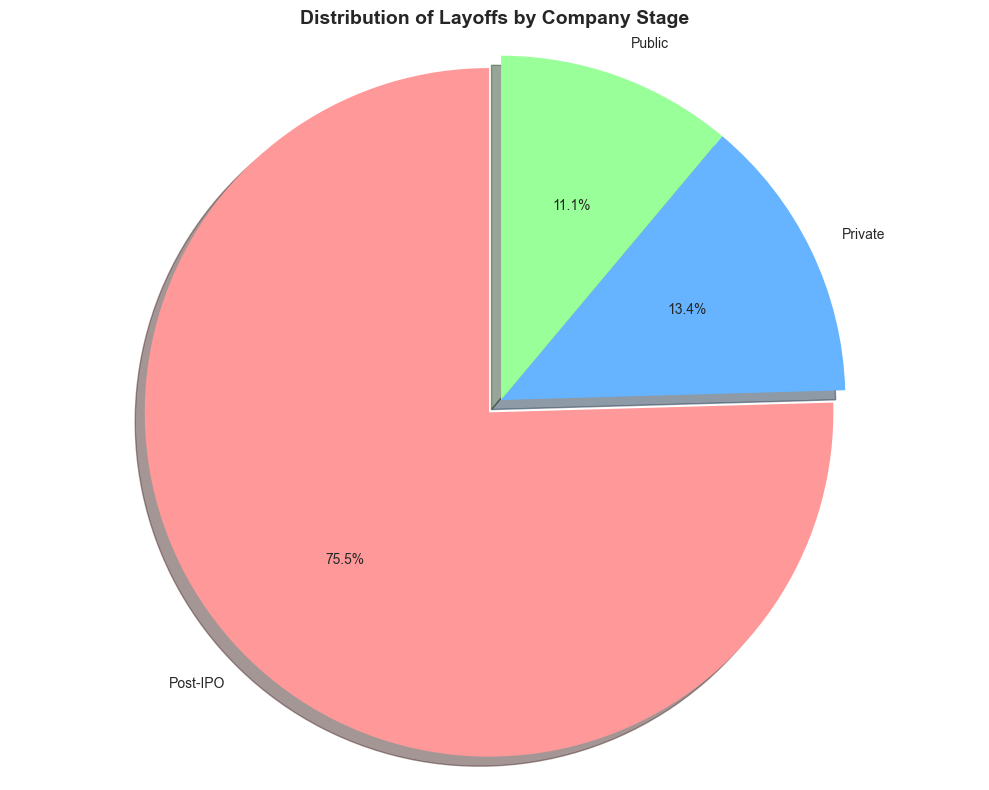

In [ ]:
plt.figure(figsize=(10, 8))
stage_data = df_clean[df_clean['total_laid_off'] > 0].groupby('stage')['total_laid_off'].sum().sort_values(ascending=False)
colors_stage = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
explode = [0.05 if i == 0 else 0 for i in range(len(stage_data))]

plt.pie(stage_data.values, labels=stage_data.index, autopct='%1.1f%%', startangle=90,
        colors=colors_stage, explode=explode, shadow=True)
plt.title('Distribution of Layoffs by Company Stage', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig('.../visualizations/layoffs_by_stage.png', dpi=300, bbox_inches='tight')
plt.show()

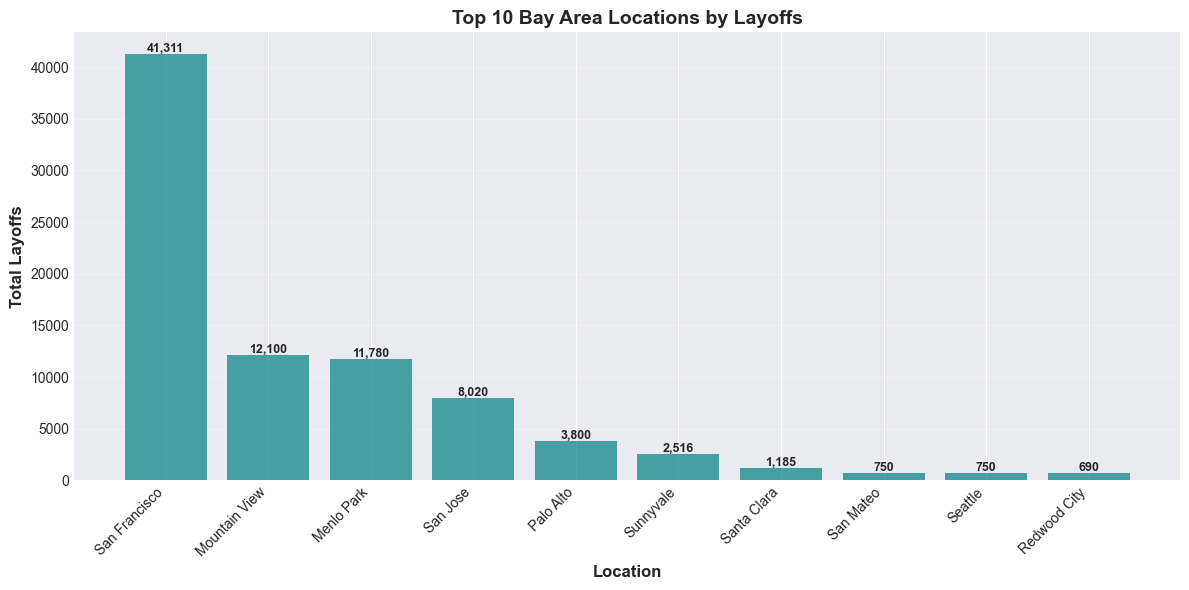

In [ ]:
plt.figure(figsize=(12, 6))
top_locations = location_layoffs.head(10)
plt.bar(range(len(top_locations)), top_locations['total_laid_off'], color='teal', alpha=0.7)
plt.xticks(range(len(top_locations)), top_locations.index, rotation=45, ha='right')
plt.xlabel('Location', fontsize=12, fontweight='bold')
plt.ylabel('Total Layoffs', fontsize=12, fontweight='bold')
plt.title('Top 10 Bay Area Locations by Layoffs', fontsize=14, fontweight='bold')
for i, v in enumerate(top_locations['total_laid_off']):
    plt.text(i, v + 200, f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('.../visualizations/layoffs_by_location.png', dpi=300, bbox_inches='tight')
plt.show()

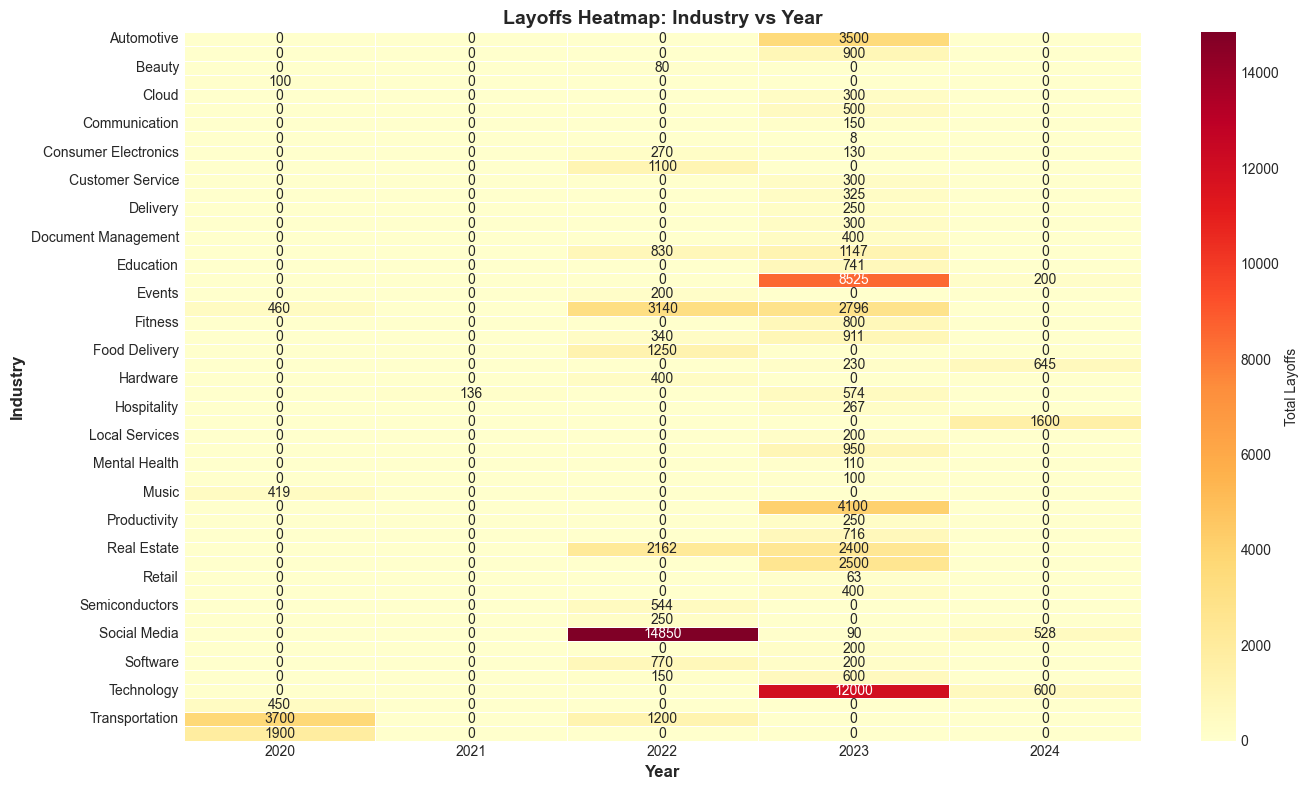

In [ ]:
plt.figure(figsize=(14, 8))
heatmap_data = df_clean[df_clean['total_laid_off'] > 0].pivot_table(
    values='total_laid_off', 
    index='industry', 
    columns='year', 
    aggfunc='sum', 
    fill_value=0
)

sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Total Layoffs'})
plt.title('Layoffs Heatmap: Industry vs Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Industry', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('.../visualizations/layoffs_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
worst_year = yearly_layoffs.idxmax()
worst_year_layoffs = yearly_layoffs.max()
print(f"\n1. WORST YEAR FOR LAYOFFS:")
print(f"   {worst_year} had {worst_year_layoffs:,.0f} layoffs in the Bay Area")

top_industry = industry_layoffs.index[0]
top_industry_layoffs = industry_layoffs.iloc[0]['total_laid_off']
print(f"\n2. HARDEST HIT INDUSTRY:")
print(f"   {top_industry} experienced {top_industry_layoffs:,.0f} layoffs")

top_stage = stage_layoffs.index[0]
top_stage_layoffs = stage_layoffs.iloc[0]['total_laid_off']
print(f"\n3. MOST AFFECTED COMPANY STAGE:")
print(f"   {top_stage} companies had {top_stage_layoffs:,.0f} layoffs")

top_city = location_layoffs.index[0]
top_city_layoffs = location_layoffs.iloc[0]['total_laid_off']
print(f"\n4. BAY AREA EPICENTER:")
print(f"   {top_city} led with {top_city_layoffs:,.0f} layoffs")

shutdown_companies = df_clean[df_clean['percentage_laid_off'] == 100]['company'].unique()
print(f"\n5. COMPANIES THAT SHUT DOWN (100% layoffs):")
print(f"   {len(shutdown_companies)} companies completely shut down")
print(f"   Examples: {', '.join(shutdown_companies[:5])}")


1. WORST YEAR FOR LAYOFFS:
   2023 had 47,933 layoffs in the Bay Area

2. HARDEST HIT INDUSTRY:
   Social Media experienced 15,468 layoffs

3. MOST AFFECTED COMPANY STAGE:
   Post-IPO companies had 65,044 layoffs

4. BAY AREA EPICENTER:
   San Francisco led with 41,311 layoffs

5. COMPANIES THAT SHUT DOWN (100% layoffs):
   3 companies completely shut down
   Examples: Bird, Trulia, Glu Mobile


In [ ]:
conn.close()